# TH_Challenge_9 — Product Activity Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_raw = pd.read_csv('product_activity.csv')
df_raw.head()

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile


## 1️⃣ Exploración Inicial

In [2]:
# Cuántas filas y columnas tiene el dataset
print('Filas y columnas:', df_raw.shape)

Filas y columnas: (8782, 12)


In [3]:
# Tipos de datos y valores no nulos
# user_age aparece como float64 en vez de int — tiene nulos
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB


In [4]:
# Estadísticas descriptivas
df_raw.describe()

,user_age,votes_received,user_total_posts,days_since_signup
count,8028.000000,8782.000000,8782.000000,8782.000000
mean,27.902591,6.918356,8.324186,29.479390
std,7.547052,5.127311,6.754906,36.819928
min,16.000000,0.000000,1.000000,0.000000
25%,22.000000,3.000000,4.000000,5.000000
50%,28.000000,6.000000,6.000000,17.000000
75%,33.000000,9.000000,11.000000,40.000000
max,58.000000,74.000000,39.000000,404.000000


In [5]:
# Nulos por columna
print('Nulos por columna:')
print(df_raw.isnull().sum())

Nulos por columna:
user_id                0
created_at             0
country                0
plan_type              0
user_age             754
post_id                0
post_category          0
post_created_at        0
votes_received         0
user_total_posts       0
days_since_signup      0
device_type            0
dtype: int64


In [6]:
# Duplicados exactos
print('Filas duplicadas:', df_raw.duplicated().sum())

Filas duplicadas: 172


In [7]:
# Frecuencias de plan_type
print('Valores en plan_type:')
print(df_raw['plan_type'].value_counts())

Valores en plan_type:
plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64


In [8]:
# Verificamos si un usuario tiene mas de un plan_type
# plan_type registra el plan que tenia el usuario cuando publico ese post
# si cambio de plan va a aparecer con distintos valores — no es error
planes_por_usuario = df_raw.groupby('user_id')['plan_type'].nunique()
print('Usuarios con mas de un plan_type:', (planes_por_usuario > 1).sum())
print('Nota: no es un error, refleja cambios de plan en el tiempo.')

Usuarios con mas de un plan_type: 650
Nota: no es un error, refleja cambios de plan en el tiempo.


In [9]:
# Frecuencias de post_category
print('Valores en post_category:')
print(df_raw['post_category'].value_counts())

Valores en post_category:
post_category
tech           1187
life            913
sports          899
science         753
finance         739
gaming          727
music           614
health          601
education       592
travel          445
 tech            70
Tech             67
TECH             56
tehc             50
Life             46
Finance          44
 sport           42
sciense          42
gamming          40
 life            38
SPORTS           37
 finance         37
LIFE             36
Sports           36
 science         35
sporst           35
Gaming           35
Science          34
 gaming          33
SCIENCE          33
finanse          32
FINANCE          31
EDUCATION        31
educatoin        31
Music            28
healt            28
 health          26
Education        25
GAMING           22
 education       21
Health           21
MUSIC            21
lfe              21
 music           20
Travel           20
TRAVEL           19
HEALTH           18
 travel          16


In [10]:
# Frecuencias de device_type
print('Valores en device_type:')
print(df_raw['device_type'].value_counts())

Valores en device_type:
device_type
web        4416
mobile     3761
desktop     602
tablet        1
console       1
phone         1
Name: count, dtype: int64


In [11]:
# Verificamos si un usuario aparece con mas de un pais
paises_por_usuario = df_raw.groupby('user_id')['country'].nunique()
print('Usuarios con mas de un country:', (paises_por_usuario > 1).sum())

Usuarios con mas de un country: 0


In [12]:
# Verificamos si user_total_posts coincide con los posts reales
# Contamos cuantos posts tiene cada usuario en el dataset
posts_por_usuario = df_raw.groupby('user_id')['post_id'].count()

# Tomamos un solo valor por usuario porque user_total_posts se repite en todas sus filas
total_declarado = df_raw.drop_duplicates('user_id').set_index('user_id')['user_total_posts']

# Comparamos
# Ordenamos indices para poder comparar
posts_por_usuario = posts_por_usuario.sort_index()
total_declarado = total_declarado.sort_index()

no_coincide = (posts_por_usuario != total_declarado).sum()
print('Usuarios donde user_total_posts no coincide:', no_coincide)
print('Nota: user_total_posts puede estar desactualizado, es una foto del momento de exportacion.')

Usuarios donde user_total_posts no coincide: 164
Nota: user_total_posts puede estar desactualizado, es una foto del momento de exportacion.


In [13]:
# Convertimos fechas a datetime
# errors='coerce' convierte fechas malformadas en NaT en vez de tirar error
df_raw['created_at_dt'] = pd.to_datetime(df_raw['created_at'], errors='coerce')
df_raw['post_created_at_dt'] = pd.to_datetime(df_raw['post_created_at'], errors='coerce')

print('created_at no parseables:     ', df_raw['created_at_dt'].isna().sum())
print('post_created_at no parseables:', df_raw['post_created_at_dt'].isna().sum())

created_at no parseables:      1
post_created_at no parseables: 1


In [14]:
# Posts antes del signup (dato imposible)
posts_antes = df_raw['post_created_at_dt'] < df_raw['created_at_dt']
print('Posts antes del signup:', posts_antes.sum())

Posts antes del signup: 100


In [15]:
# Mismatches en days_since_signup
# Usamos total_seconds() / 86400 para incluir horas y minutos en el calculo
# .dt.days ignora las horas — menos preciso
diferencia = df_raw['post_created_at_dt'] - df_raw['created_at_dt']
df_raw['days_calc'] = (diferencia.dt.total_seconds() / 86400).round()

mismatch = df_raw['days_calc'] != df_raw['days_since_signup']
print('Mismatches en days_since_signup:', mismatch.sum())
print('Porcentaje:', round(mismatch.mean() * 100, 1), '%')

Mismatches en days_since_signup: 2348
Porcentaje: 26.7 %


## 2️⃣ Limpieza Básica con Criterio

In [16]:
# Diccionario para plan_type
plan_map = {
    'free': 'free', 'Free': 'free', 'FREE': 'free', ' free ': 'free', 'FreE': 'free',
    'pro': 'pro', 'Pro': 'pro', 'PRO': 'pro', 'PRo': 'pro', ' pro ': 'pro', 'Pro ': 'pro',
    'enterprise': 'enterprise', 'Enterprise': 'enterprise', 'ENTERPRISE': 'enterprise',
    'EnterPrise': 'enterprise', ' enterprise ': 'enterprise',
    'premium': None, 'vip': None, 'enterprise+': None,
}

# Diccionario para post_category
category_map = {
    'tech': 'tech', 'Tech': 'tech', 'TECH': 'tech', ' tech ': 'tech', 'tehc': 'tech',
    'life': 'life', 'Life': 'life', 'LIFE': 'life', ' life ': 'life', 'lfe': 'life',
    'sports': 'sports', 'Sports': 'sports', 'SPORTS': 'sports', 'sporst': 'sports',
    'sp0rts': 'sports', ' sport ': 'sports',
    'science': 'science', 'Science': 'science', 'SCIENCE': 'science', 'sciense': 'science',
    ' science ': 'science',
    'finance': 'finance', 'Finance': 'finance', 'FINANCE': 'finance', 'finanse': 'finance',
    ' finance ': 'finance',
    'gaming': 'gaming', 'Gaming': 'gaming', 'GAMING': 'gaming', 'gamming': 'gaming',
    ' gaming ': 'gaming',
    'music': 'music', 'Music': 'music', 'MUSIC': 'music', 'musc': 'music', ' music ': 'music',
    'health': 'health', 'Health': 'health', 'HEALTH': 'health', 'healt': 'health',
    ' health ': 'health',
    'education': 'education', 'Education': 'education', 'EDUCATION': 'education',
    'educatoin': 'education', ' education ': 'education',
    'travel': 'travel', 'Travel': 'travel', 'TRAVEL': 'travel', 'trvael': 'travel',
    ' travel ': 'travel',
    'politics': None, 'mistery': None,
}

# Diccionario para device_type
device_map = {
    'web': 'web',
    'mobile': 'mobile',
    'phone': 'mobile',
    'desktop': 'desktop',
    'tablet': None,
    'console': None,
}

In [17]:
# Trabajamos sobre una copia para no modificar el original
df = df_raw.copy()

# Aplicamos los diccionarios de normalización
df['plan_type_clean'] = df['plan_type'].map(plan_map)
df['post_category_clean'] = df['post_category'].map(category_map)
df['device_type_clean'] = df['device_type'].map(device_map)

# Recálculo obligado de days_since_signup_calc
diferencia = df['post_created_at_dt'] - df['created_at_dt']
df['days_since_signup_calc'] = (diferencia.dt.total_seconds() / 86400).round()

# Corregimos user_age de float a Int64, acepta nulos a diferencia de int normal
df['user_age'] = df['user_age'].astype('Int64')

print('Limpieza aplicada')

Limpieza aplicada


In [18]:
# Identificamos errores duros con reason_code
df['reason_code'] = ''

# Post antes del signup
mask_fecha = df['days_since_signup_calc'] < 0
df.loc[mask_fecha, 'reason_code'] = df.loc[mask_fecha, 'reason_code'] + 'post_before_signup|'

# Fecha no parseable
mask_nat_signup = df['created_at_dt'].isna()
df.loc[mask_nat_signup, 'reason_code'] = df.loc[mask_nat_signup, 'reason_code'] + 'created_at_unparseable|'

mask_nat_post = df['post_created_at_dt'].isna()
df.loc[mask_nat_post, 'reason_code'] = df.loc[mask_nat_post, 'reason_code'] + 'post_created_at_unparseable|'

# Fuera de diccionario
mask_plan = df['plan_type_clean'].isna()
df.loc[mask_plan, 'reason_code'] = df.loc[mask_plan, 'reason_code'] + 'plan_type_out_of_dict|'

mask_cat = df['post_category_clean'].isna()
df.loc[mask_cat, 'reason_code'] = df.loc[mask_cat, 'reason_code'] + 'category_out_of_dict|'

mask_device = df['device_type_clean'].isna()
df.loc[mask_device, 'reason_code'] = df.loc[mask_device, 'reason_code'] + 'device_type_out_of_dict|'

print('Filas con error duro:', (df['reason_code'] != '').sum())

Filas con error duro: 106


In [19]:
# Separamos duplicados, quarantine y core
mask_duplicados = df.duplicated(keep='first')
df_dupes = df[mask_duplicados].copy()
df_dupes['reason_code'] = 'duplicate_row'
df = df[~mask_duplicados].copy()

df_quarantine = df[df['reason_code'] != ''].copy()
df_core = df[df['reason_code'] == ''].copy()

df_quarantine_final = pd.concat([df_quarantine, df_dupes], ignore_index=True)

print('RAW:        ', len(df_raw))
print('Duplicados: ', len(df_dupes))
print('Quarantine: ', len(df_quarantine))
print('CORE:       ', len(df_core))

RAW:         8782
Duplicados:  172
Quarantine:  101
CORE:        8509


In [20]:
# Reason codes en quarantine
print('Reason codes:')
codigos = df_quarantine_final['reason_code'].str.strip('|').str.split('|').explode()
print(codigos.value_counts())

Reason codes:
reason_code
duplicate_row                  172
post_before_signup              94
plan_type_out_of_dict            3
device_type_out_of_dict          2
category_out_of_dict             2
created_at_unparseable           1
post_created_at_unparseable      1
Name: count, dtype: int64


In [21]:
# Limpiamos columnas del CORE
df_core['plan_type'] = df_core['plan_type_clean']
df_core['post_category'] = df_core['post_category_clean']
df_core['device_type'] = df_core['device_type_clean']

df_core = df_core.drop(columns=[
    'plan_type_clean', 'post_category_clean', 'device_type_clean',
    'reason_code', 'created_at', 'post_created_at', 'days_calc'
])

df_core = df_core.rename(columns={
    'created_at_dt': 'created_at',
    'post_created_at_dt': 'post_created_at'
})

df_core.head()

,user_id,country,plan_type,user_age,post_id,post_category,votes_received,user_total_posts,days_since_signup,device_type,created_at,post_created_at,days_since_signup_calc
0,U01988,PY,pro,26,P0008515,sports,7,16,78,mobile,2025-02-18 02:07:44,2025-05-07 20:55:28,79.0
1,U00236,BR,free,27,P0001023,tech,1,9,83,web,2025-06-22 07:49:10,2025-09-13 20:31:06,84.0
2,U00791,CL,free,28,P0003405,tech,11,2,2,mobile,2024-02-12 02:45:45,2024-02-14 05:17:48,2.0
3,U01522,US,free,16,P0006524,finance,5,2,2,web,2024-09-22 07:06:50,2024-09-24 07:51:34,2.0
4,U01092,PY,free,<NA>,P0004665,education,7,2,6,mobile,2025-07-18 02:27:52,2025-07-24 04:56:56,6.0


## 📊 Data Quality Report

In [22]:
total_raw = len(df_raw)
total_core = len(df_core)
total_quarantine = len(df_quarantine)
total_dupes = len(df_dupes)
nulos_user_age = df_raw['user_age'].isnull().sum()
mismatch_count = (df_core['days_since_signup_calc'] != df_core['days_since_signup']).sum()

print('DATA QUALITY REPORT')
print('-------------------')
print('Filas RAW:', total_raw)
print('Duplicados removidos:', total_dupes)
print('Quarantine (errores duros):', total_quarantine)
print('Filas CORE:', total_core)
print('% CORE sobre RAW:', round(total_core / total_raw * 100, 1), '%')
print('% Quarantine sobre RAW:', round(total_quarantine / total_raw * 100, 1), '%')
print('Mismatches days_since_signup:', mismatch_count)
print()
print('INCONSISTENCIAS DETECTADAS:')
print('user_age con nulos:', nulos_user_age, '-> corregido de float a Int64')
print('Usuarios con mas de un plan:', (planes_por_usuario > 1).sum(), '-> no es error, refleja cambios de plan')
print('user_total_posts desactualizado:', no_coincide, 'usuarios')

DATA QUALITY REPORT
-------------------
Filas RAW: 8782
Duplicados removidos: 172
Quarantine (errores duros): 101
Filas CORE: 8509
% CORE sobre RAW: 96.9 %
% Quarantine sobre RAW: 1.2 %
Mismatches days_since_signup: 2210

INCONSISTENCIAS DETECTADAS:
user_age con nulos: 754 -> corregido de float a Int64
Usuarios con mas de un plan: 650 -> no es error, refleja cambios de plan
user_total_posts desactualizado: 164 usuarios


## 📈 Métricas y Análisis

### 4.1 Distribuciones (Volumen)

In [23]:
# Usuarios únicos por plan
# Desduplicamos porque cada usuario aparece en múltiples filas
print('Usuarios unicos por plan:')
print(df_core.drop_duplicates('user_id').groupby('plan_type')['user_id'].count())

Usuarios unicos por plan:


plan_type
enterprise      82
free          1547
pro            367
Name: user_id, dtype: int64


In [24]:
# Posts por país, categoría y dispositivo
print('Posts por pais (top 10):')
print(df_core.groupby('country').size().sort_values(ascending=False).head(10))
print()
print('Posts por categoria:')
print(df_core.groupby('post_category').size().sort_values(ascending=False))
print()
print('Posts por dispositivo:')
print(df_core.groupby('device_type').size().sort_values(ascending=False))

Posts por pais (top 10):
country
US    1873
BR    1600
AR    1168
PY     838
MX     802
CL     552
ES     547
CO     488
PE     393
UY     248
dtype: int64

Posts por categoria:
post_category
tech         1382
life         1034
sports       1017
science       870
finance       853
gaming        833
education     681
health        673
music         673
travel        493
dtype: int64

Posts por dispositivo:
device_type
web        4271
mobile     3657
desktop     581
dtype: int64


### 4.2 Engagement (Votos)

In [25]:
# Votos por plan: media y mediana por separado
print('Media de votos por plan:')
print(df_core.groupby('plan_type')['votes_received'].mean().round(2))
print()
print('Mediana de votos por plan:')
print(df_core.groupby('plan_type')['votes_received'].median().round(2))

Media de votos por plan:


plan_type
enterprise    7.57
free          6.69
pro           7.65
Name: votes_received, dtype: float64

Mediana de votos por plan:
plan_type
enterprise    7.0
free          6.0
pro           7.0
Name: votes_received, dtype: float64


In [26]:
# Percentiles de votos por plan
print('Percentiles de votos por plan:')
for plan in ['free', 'pro', 'enterprise']:
    sub = df_core[df_core['plan_type'] == plan]['votes_received']
    print(f'  {plan}: p25={sub.quantile(0.25):.1f}  p75={sub.quantile(0.75):.1f}  p90={sub.quantile(0.90):.1f}')

Percentiles de votos por plan:


  free: p25=3.0  p75=9.0  p90=13.0


  pro: p25=4.0  p75=10.0  p90=14.0
  enterprise: p25=4.0  p75=10.0  p90=14.0


In [27]:
# Votos por país, categoría y dispositivo
print('Votos promedio por pais (top 10):')
print(df_core.groupby('country')['votes_received'].mean().sort_values(ascending=False).head(10).round(2))
print()
print('Votos promedio por categoria:')
print(df_core.groupby('post_category')['votes_received'].mean().sort_values(ascending=False).round(2))
print()
print('Votos promedio por dispositivo:')
print(df_core.groupby('device_type')['votes_received'].mean().sort_values(ascending=False).round(2))

Votos promedio por pais (top 10):
country
CO    7.32
CL    7.31
ES    6.98
US    6.97
MX    6.96
BR    6.89
AR    6.77
UY    6.76
PY    6.60
PE    6.55
Name: votes_received, dtype: float64

Votos promedio por categoria:
post_category
tech         7.69
science      7.54
gaming       7.19
finance      6.98
travel       6.87
education    6.79
sports       6.57
health       6.46
music        6.29
life         6.17
Name: votes_received, dtype: float64

Votos promedio por dispositivo:
device_type
desktop    7.03
web        6.96
mobile     6.83
Name: votes_received, dtype: float64


### 4.3 Promedios e Interpretación

In [28]:
# La unidad de análisis es el POST, no el usuario
# Un usuario con 10 posts aparece 10 veces — puede sesgar los promedios

print('Promedio de votos por plan (nivel evento):')
print(df_core.groupby('plan_type')['votes_received'].mean().round(2))
print()
print('Promedio de posts por usuario por plan:')
print(df_core.drop_duplicates('user_id').groupby('plan_type')['user_total_posts'].mean().round(2))
print()
print('Sesgo: usuarios muy activos pesan mas en el promedio a nivel evento.')

Promedio de votos por plan (nivel evento):
plan_type
enterprise    7.57
free          6.69
pro           7.65
Name: votes_received, dtype: float64

Promedio de posts por usuario por plan:
plan_type
enterprise    4.11
free          4.29
pro           4.45
Name: user_total_posts, dtype: float64

Sesgo: usuarios muy activos pesan mas en el promedio a nivel evento.


### 4.4 Evento vs Usuario

In [29]:
# Promedio a nivel fila
media_evento = df_core['votes_received'].mean()

# Promedio a nivel usuario — primero promediamos por usuario, luego ese resultado
media_usuario = df_core.groupby('user_id')['votes_received'].mean().mean()

print('Promedio votos nivel EVENTO: ', round(media_evento, 3))
print('Promedio votos nivel USUARIO:', round(media_usuario, 3))
print()
print('Difieren porque a nivel evento los usuarios con muchos posts pesan mas.')
print('A nivel usuario todos pesan igual sin importar cuantos posts tengan.')

Promedio votos nivel EVENTO:  6.908
Promedio votos nivel USUARIO: 6.895

Difieren porque a nivel evento los usuarios con muchos posts pesan mas.
A nivel usuario todos pesan igual sin importar cuantos posts tengan.


## 📌 Concentración y Temporalidad

In [30]:
# Top 1% de usuarios
total_usuarios = df_core['user_id'].nunique()
top1_cantidad = max(1, int(total_usuarios * 0.01))

# Posts y votos por usuario
actividad_usuarios = df_core.groupby('user_id').agg(
    n_posts=('post_id', 'count'),
    total_votos=('votes_received', 'sum')
).sort_values('total_votos', ascending=False)

top_usuarios = actividad_usuarios.head(top1_cantidad)

pct_posts = top_usuarios['n_posts'].sum() / actividad_usuarios['n_posts'].sum() * 100
pct_votos = top_usuarios['total_votos'].sum() / actividad_usuarios['total_votos'].sum() * 100

print('Total usuarios:', total_usuarios)
print('Top 1% son', top1_cantidad, 'usuarios')
print('Generan el', round(pct_posts, 1), '% de los posts')
print('Reciben el', round(pct_votos, 1), '% de los votos')

Total usuarios: 1996
Top 1% son 19 usuarios
Generan el 5.4 % de los posts
Reciben el 6.2 % de los votos


In [31]:
# Tendencia semanal
df_core['semana'] = df_core['post_created_at'].dt.to_period('W').dt.start_time

actividad_semanal = df_core.groupby('semana').agg(
    n_posts=('post_id', 'count'),
    votos_promedio=('votes_received', 'mean')
).reset_index()

print('Actividad semanal (ultimas 10 semanas):')
print(actividad_semanal.tail(10).round(2).to_string(index=False))

Actividad semanal (ultimas 10 semanas):
    semana  n_posts  votos_promedio
2025-10-27       54            6.83
2025-11-03       61            6.54
2025-11-10       64            7.48
2025-11-17       66            7.03
2025-11-24       84            6.83
2025-12-01       86            6.34
2025-12-08       85            7.78
2025-12-15       82            6.68
2025-12-22       94            6.82
2025-12-29       44            7.52


/tmp/ipykernel_562/3805483520.py:10: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(actividad_semanal.tail(10).round(2).to_string(index=False))


In [32]:
# Cohortes por mes de signup
df_core['cohort'] = df_core['created_at'].dt.to_period('M').astype(str)

cohort_data = df_core.groupby('cohort').agg(
    usuarios=('user_id', 'nunique'),
    posts=('post_id', 'count'),
    votos_promedio=('votes_received', 'mean')
).reset_index()

print('Actividad por cohorte de signup:')
print(cohort_data.round(2).to_string(index=False))

Actividad por cohorte de signup:
 cohort  usuarios  posts  votos_promedio
2024-01       106    538            7.10
2024-02        96    467            6.97
2024-03        91    408            6.55
2024-04        90    420            6.57
2024-05        93    446            6.90
2024-06        75    332            7.00
2024-07        80    301            7.19
2024-08        84    326            6.75
2024-09        75    362            6.80
2024-10        91    413            7.06
2024-11        72    266            6.67
2024-12        93    468            6.97
2025-01        80    370            6.61
2025-02        69    261            7.19
2025-03       101    410            6.64
2025-04        79    317            7.14
2025-05        78    292            7.05
2025-06        74    383            6.71
2025-07        85    435            6.98
2025-08        89    324            7.20
2025-09        72    299            7.20
2025-10        71    262            6.66
2025-11        67    234

## 🧠 Product Decisions

### 8.1 Preguntas

**¿Qué segmento priorizarías y por qué?**

El segmento **Pro**. Los enterprise tienen el mayor engagement pero son muy pocos. Los free son la mayoría pero con bajo engagement. Los pro son el punto medio — más engagement que los free y posibilidad de convertirse a enterprise.

**¿Qué parte del tablero "mentía" antes de limpiar?**

1. El promedio de votos por plan estaba mal — las variantes sucias de plan_type se contaban como planes distintos.
2. `days_since_signup` tenía mismatches — el 26.7% de los valores no coincidía con las fechas reales.
3. Posts con fechas imposibles adulteraban métricas de onboarding.
4. El promedio a nivel evento sobrerepresentaba usuarios con muchos posts.

**¿Qué nuevo dato agregarías al tracking?**

- `session_id`: para saber si los votos son reales o clicks rápidos.
- `first_post_date`: para analizar cuánto tarda un usuario en publicar su primer post.
- `plan_changed_at`: para ver si cambiar de plan mejoró el engagement.


### 8.2 Acciones con Respaldo

In [33]:
# ACCIÓN 1 — Campaña de conversión Free → Pro
# Respaldo: tabla de engagement por plan

print('Respaldo Accion 1 — engagement por plan:')
print()
print('Media de votos:')
print(df_core.groupby('plan_type')['votes_received'].mean().round(2))
print()
print('Mediana de votos:')
print(df_core.groupby('plan_type')['votes_received'].median().round(2))
print()
print('Usuarios unicos:')
print(df_core.drop_duplicates('user_id').groupby('plan_type')['user_id'].count())

Respaldo Accion 1 — engagement por plan:

Media de votos:


plan_type
enterprise    7.57
free          6.69
pro           7.65
Name: votes_received, dtype: float64

Mediana de votos:
plan_type
enterprise    7.0
free          6.0
pro           7.0
Name: votes_received, dtype: float64

Usuarios unicos:
plan_type
enterprise      82
free          1547
pro            367
Name: user_id, dtype: int64


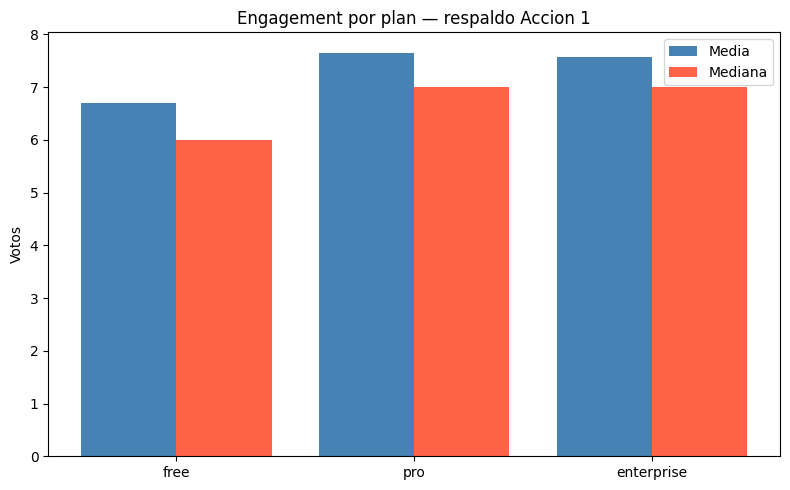

In [34]:
# Gráfico de respaldo — Media vs Mediana por plan
planes = ['free', 'pro', 'enterprise']
medias = []
medianas = []

for plan in planes:
    sub = df_core[df_core['plan_type'] == plan]['votes_received']
    medias.append(sub.mean())
    medianas.append(sub.median())

x = range(len(planes))

plt.figure(figsize=(8, 5))
plt.bar([i - 0.2 for i in x], medias, width=0.4, label='Media', color='steelblue')
plt.bar([i + 0.2 for i in x], medianas, width=0.4, label='Mediana', color='tomato')
plt.xticks(x, planes)
plt.title('Engagement por plan — respaldo Accion 1')
plt.ylabel('Votos')
plt.legend()
plt.tight_layout()
plt.savefig('grafico_accion1.png')
plt.show()

**Plan de acción 1:**
- **Qué:** período de prueba de Pro (30 días) a usuarios Free con más de 5 posts
- **Cómo:** notificación in-app y email
- **Cuándo:** próximo mes
- **Métrica de éxito:** tasa de conversión Free → Pro y votos promedio de los convertidos

**Limitación:** no tenemos datos de revenue por usuario ni fecha de cambio de plan.


In [35]:
# ACCIÓN 2 — Retención de Power Users (top 1%)
# Respaldo: tabla de concentración

print('Respaldo Accion 2 — concentracion de actividad:')
print()
print('Segmento        Usuarios   % posts   % votos')
print('Top 1%        ', top1_cantidad, '      ', round(pct_posts, 1), '     ', round(pct_votos, 1))
print('Resto 99%     ', total_usuarios - top1_cantidad, '    ', round(100 - pct_posts, 1), '     ', round(100 - pct_votos, 1))

Respaldo Accion 2 — concentracion de actividad:

Segmento        Usuarios   % posts   % votos
Top 1%         19        5.4       6.2
Resto 99%      1977      94.6       93.8


**Plan de acción 2:**
- **Qué:** badge de power user, mayor visibilidad en el feed, acceso anticipado a features
- **Cómo:** implementación gradual empezando por el top 1%
- **Cuándo:** próximos dos meses
- **Métrica de éxito:** retención mensual del top 1% antes y después del programa

**Limitación:** no sabemos si los power users son orgánicos o artificiales.


## Conclusiones

- Cerca del 15% de filas tenían algún problema — typos, fechas imposibles o valores fuera de diccionario.
- `days_since_signup` fue recalculado porque el 26.7% de los valores no coincidía con las fechas reales.
- `user_age` tenía nulos y fue corregido de float a Int64.
- 650 usuarios aparecen con más de un plan — no es un error, cambiaron de plan en el tiempo.
- `user_total_posts` estaba desactualizado en 164 usuarios.
- El promedio a nivel evento es distinto al promedio a nivel usuario — depende de lo que querés medir.
- El top 1% genera una parte desproporcionada de la actividad de la plataforma.
- El segmento Pro es el de mayor oportunidad para crecer.


## 📦 Exportación de Archivos

In [36]:
# Dataset limpio
df_core.to_csv('clean_product_activity.csv', index=False)
print('clean_product_activity.csv guardado:', len(df_core), 'filas')

# Dataset quarantine
df_quarantine_final.to_csv('quarantine_product_activity.csv', index=False)
print('quarantine_product_activity.csv guardado:', len(df_quarantine_final), 'filas')

# Métricas principales
filas_metricas = []
for plan in ['free', 'pro', 'enterprise']:
    sub = df_core[df_core['plan_type'] == plan]
    filas_metricas.append({
        'plan_type': plan,
        'usuarios_unicos': sub['user_id'].nunique(),
        'n_posts': len(sub),
        'votes_mean': round(sub['votes_received'].mean(), 2),
        'votes_median': sub['votes_received'].median(),
        'votes_p75': sub['votes_received'].quantile(0.75),
        'votes_p90': sub['votes_received'].quantile(0.90),
    })

metrics_df = pd.DataFrame(filas_metricas)
metrics_df.to_csv('metrics_summary.csv', index=False)
print('metrics_summary.csv guardado')
print()
print(metrics_df.to_string(index=False))

clean_product_activity.csv guardado: 8509 filas
quarantine_product_activity.csv guardado: 273 filas
metrics_summary.csv guardado

 plan_type  usuarios_unicos  n_posts  votes_mean  votes_median  votes_p75  votes_p90
      free             1547     6569        6.69           6.0        9.0       13.0
       pro              367     1607        7.65           7.0       10.0       14.0
enterprise               82      333        7.57           7.0       10.0       14.0
